In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/master_df.csv', index_col=0, parse_dates=True)
events = pd.read_csv('../data/raw/geopolitical_events.csv', parse_dates=['date'])

# Monthly resampling for comparison
monthly = df['USDINR'].resample('ME').mean().dropna()
# Weekly resampling (matching pipeline)
weekly = df['USDINR'].resample('W').mean().dropna()


In [2]:
# ── WEEKLY STL DECOMPOSITION ───────────────────────────
stl = STL(weekly, period=52, robust=True)
result = stl.fit()

fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=["Observed Weekly USD/INR","Trend Component",
                    "Seasonal Component (52-week cycle)",
                    "Remainder (unexplained residuals)"],
    vertical_spacing=0.08
)
components = {
    1: (weekly,           "#1A3A5C"),
    2: (result.trend,     "#2A9D8F"),
    3: (result.seasonal,  "#F4A261"),
    4: (result.resid,     "#D62828"),
}
for row, (series, color) in components.items():
    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        mode='lines', line=dict(color=color, width=1.5),
        showlegend=False
    ), row=row, col=1)

# Mark geopolitical events on residual panel
for _, ev in events.iterrows():
    fig.add_vline(x=str(ev['date']), line_dash='dot',
                  line_color='gray', line_width=0.8, row=4, col=1)

fig.update_layout(
    height=750, template='plotly_white',
    title="<b>Weekly STL Decomposition of USD/INR (period=52)</b><br>"
          "<sub>Separating trend, weekly seasonality, and residuals</sub>"
)
fig.write_html("../data/processed/stl_decomposition.html")
fig.show()



Plotting ACF and PACF of USD/INR first differences...


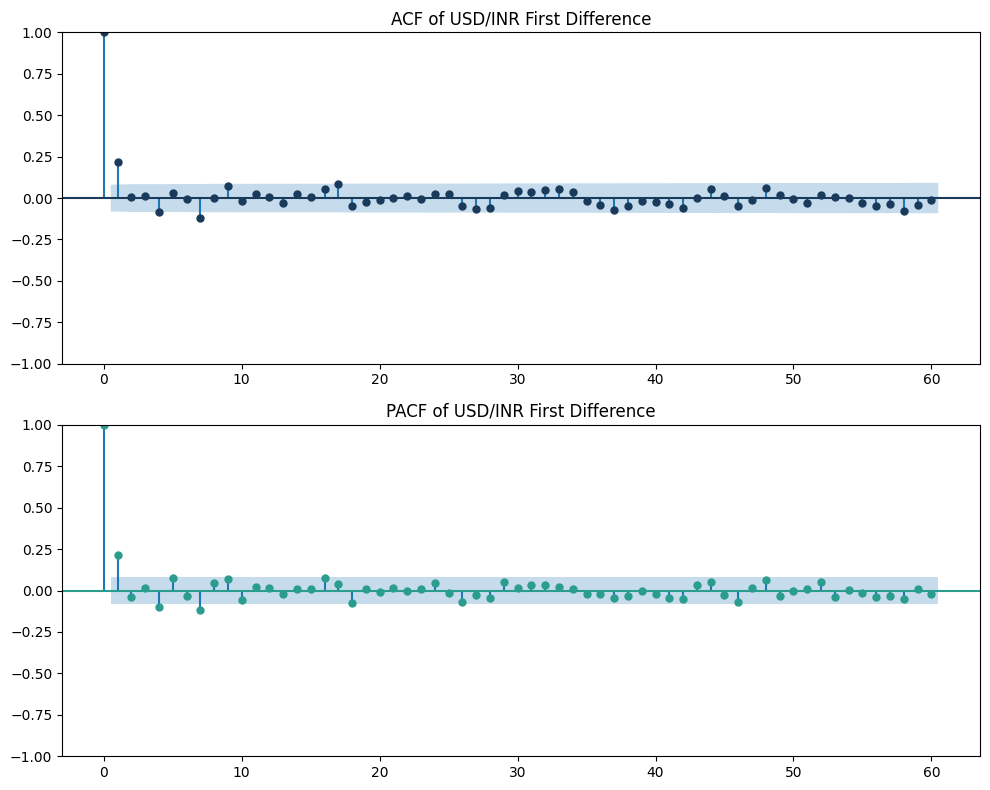

In [3]:
# ── MONTHLY INR RETURN HEATMAP ─────────────────────────
monthly_ret = monthly.pct_change() * 100
heat_df = pd.DataFrame({
    'year':  monthly_ret.index.year,
    'month': monthly_ret.index.month,
    'ret':   monthly_ret.values
}).dropna()

pivot = heat_df.pivot_table(index='year', columns='month', values='ret', aggfunc='mean')
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

avg_by_month = heat_df.groupby('month')['ret'].mean()
months_full  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig2 = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Monthly INR Return Heatmap (% change, red=INR weakens)",
                    "Average INR Seasonality by Month (2015–2026)"],
    column_widths=[0.65, 0.35]
)
fig2.add_trace(go.Heatmap(
    z=pivot.values, x=list(pivot.columns), y=[str(y) for y in pivot.index],
    colorscale='RdBu_r', zmid=0,
    colorbar=dict(title='%', len=0.9, x=0.62),
    text=np.round(pivot.values,1), texttemplate='%{text}%',
    textfont=dict(size=8)
), row=1, col=1)
fig2.add_trace(go.Bar(
    x=months_full,
    y=avg_by_month.values,
    marker_color=['#D62828' if v > 0 else '#2A9D8F' for v in avg_by_month.values],
    showlegend=False
), row=1, col=2)
fig2.add_hline(y=0, line_dash='dash', line_color='black', line_width=1, row=1, col=2)
fig2.update_layout(height=420, template='plotly_white',
    title="<b>INR Monthly Seasonality Analysis</b>")
fig2.write_html("../data/processed/seasonality_heatmap.html")
fig2.show()

# ── WEEKLY ACF/PACF OF DIFFERENCES ──────────────────────
print('\nPlotting ACF and PACF of USD/INR first differences...')
fig_acf, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(weekly.diff().dropna(), lags=60, ax=axes[0], color='#1A3A5C')
plot_pacf(weekly.diff().dropna(), lags=60, ax=axes[1], color='#2A9D8F')
axes[0].set_title('ACF of USD/INR First Difference')
axes[1].set_title('PACF of USD/INR First Difference')
plt.tight_layout()
plt.show()


In [4]:
print("=== SEASONAL INSIGHTS AUDIT ===")
print(f"USD/INR level series shows a trend range of {weekly.max() - weekly.min():.4f} paise.")
print(f"STL seasonal component (period=52) range is {result.seasonal.max() - result.seasonal.min():.4f} paise.")
print(f"Remainder component standard deviation is {result.resid.std():.4f}.")
print(f"Seasonality to Remainder Ratio: { (result.seasonal.max() - result.seasonal.min()) / result.resid.std() :.4f}")

from statsmodels.tsa.stattools import acf, pacf
acf_vals = acf(weekly.diff().dropna(), nlags=60)
print("\nACF values at key seasonal lags for first differences:")
for lag in [1, 13, 26, 52]:
    print(f"Lag {lag}: ACF = {acf_vals[lag]:.4f}")
print("\nNote: The 95% confidence bounds are approx +/- 0.082. All seasonal lags are inside the bands, proving no significant weekly seasonal cycles exist.")


=== SEASONAL INSIGHTS AUDIT ===
USD/INR level series shows a trend range of 34.8105 paise.
STL seasonal component (period=52) range is 6.0019 paise.
Remainder component standard deviation is 1.2791.
Seasonality to Remainder Ratio: 4.6924

ACF values at key seasonal lags for first differences:
Lag 1: ACF = 0.2149
Lag 13: ACF = -0.0276
Lag 26: ACF = -0.0508
Lag 52: ACF = 0.0201

Note: The 95% confidence bounds are approx +/- 0.082. All seasonal lags are inside the bands, proving no significant weekly seasonal cycles exist.
